# Indian Pines

In [ ]:
import numpy as np

from IPython.display import HTML
from collections import defaultdict

from src.util.hsi import (
    write_fixed_labels_mask,
    apply_mask_to_visualize,
    DimReductionType,
    PreProcessType,
)
from src.data.indian_pines import load_indian_pines
from src.visualization.plot import plot_progress_animation
from src.definitions import RAW_DATA_FOLDER
from src.util.torch import resolve_torch_device

In [2]:
random_seed = 42

device = resolve_torch_device()

In [3]:
target_dim = 75

pre_process_type = PreProcessType.STANDARTIZATION
dim_reduction_type = DimReductionType.PCA

In [4]:
file_name_prefix = f"indian-pines-train-test-split"

In [5]:
_, labels = load_indian_pines()

In [6]:
labels_arr = labels.reshape(-1)

In [7]:
ds_size = len(labels_arr)

f"Dataset size is {ds_size}"

'Dataset size is 21025'

In [8]:
unique, counts = np.unique(labels, return_counts=True)

{u: c for u, c in zip(unique, counts)}

{0: 10776,
 1: 46,
 2: 1428,
 3: 830,
 4: 237,
 5: 483,
 6: 730,
 7: 28,
 8: 478,
 9: 20,
 10: 972,
 11: 2455,
 12: 593,
 13: 205,
 14: 1265,
 15: 386,
 16: 93}

In [9]:
class_count = len(unique)

f"Class count: {class_count}"

'Class count: 17'

# Overall by class

In [10]:
mask_size_as_fraction = [
    "0.01",
    "0.02",
    "0.03",
    "0.04",
    "0.05",
    "0.06",
    "0.07",
    "0.08",
    "0.09",
    "0.10",
    "0.15",
    "0.20",
    "0.30",
    "0.40",
    "0.50",
    "0.60",
    "0.70",
    "0.80",
]

In [11]:
from sklearn.model_selection import train_test_split


all_masks = defaultdict(lambda: defaultdict(np.ndarray))

for fraction in mask_size_as_fraction:

    fraction_mask = []
    all_train_size = 0

    for label in range(class_count):
        label_indices = np.where(labels_arr == label)[0]
        labeled_count = len(label_indices)
        train_size = max(int(labeled_count * float(fraction)), 1)

        train_indices, _ = train_test_split(
            label_indices,
            train_size=train_size,
            random_state=random_seed,
            shuffle=True,
        )

        all_train_size += train_size

        label_mask = np.zeros_like(labels_arr)
        label_mask[train_indices] = 1

        write_fixed_labels_mask(
            label_mask,
            f"{file_name_prefix}-{label}-{train_size}.npy",
            folder=RAW_DATA_FOLDER / "mask" / "train-test-split",
        )

        fraction_mask.append(label_mask)

    mask = np.bitwise_or.reduce(fraction_mask)

    all_masks[all_train_size] = mask.reshape(labels.shape)

    write_fixed_labels_mask(
        mask,
        f"{file_name_prefix}-overall-{all_train_size}.npy",
        folder=RAW_DATA_FOLDER / "mask" / "train-test-split",
    )

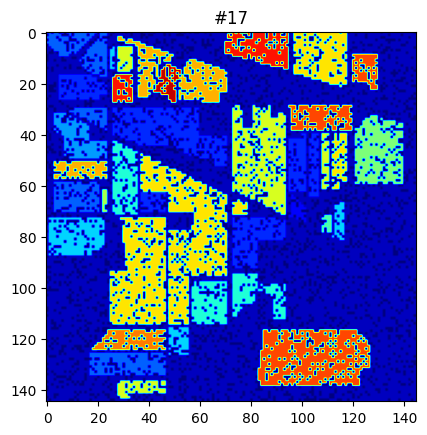

In [12]:
samples = [apply_mask_to_visualize(it, labels) for it in all_masks.values()]

ani = plot_progress_animation(samples, 18)

HTML(ani.to_jshtml())